In [1]:
# ============================================================
# CELL 1 — Import libraries
# ============================================================

import os
import requests
import pandas as pd

print("Libraries loaded ✅")

Libraries loaded ✅


In [ ]:
# ============================================================
# CELL 2 — Fetch live flights over Europe from OpenSky API
# ============================================================

USERNAME = os.getenv("OPENSKY_USER")
PASSWORD = os.getenv("OPENSKY_PASS")

# Define a bounding box around Europe
# These are latitude/longitude boundaries — think of it as a rectangle over Europe
lat_min, lat_max = 35.0, 72.0   # south to north
lon_min, lon_max = -15.0, 45.0  # west to east

url = (
    f"https://opensky-network.org/api/states/all"
    f"?lamin={lat_min}&lamax={lat_max}"
    f"&lomin={lon_min}&lomax={lon_max}"
)

print("Fetching data from OpenSky...")
response = requests.get(url, auth=(USERNAME, PASSWORD), timeout=30)

print(f"Status code: {response.status_code}")

if response.status_code == 200:
    print("✅ Data fetched successfully!")
else:
    print("❌ Something went wrong. Check your credentials.")

Fetching data from OpenSky...
Status code: 200
✅ Data fetched successfully!


In [ ]:
# ============================================================
# CELL 3 — Parse the response into a readable table
# ============================================================

data = response.json()

columns = [
    "icao24",        # Unique aircraft ID
    "callsign",      # Flight number e.g. RYR123
    "origin_country",# Country where aircraft is registered
    "time_position", # Last time position was updated
    "last_contact",  # Last time we heard from this aircraft
    "longitude",     # Current position
    "latitude",      # Current position
    "baro_altitude", # Altitude in metres
    "on_ground",     # True if on the ground
    "velocity",      # Speed in metres per second
    "true_track",    # Direction of travel in degrees
    "vertical_rate", # Climbing (+) or descending (-)
    "sensors",       # Which receivers picked this up
    "geo_altitude",  # GPS altitude in metres
    "squawk",        # Transponder code
    "spi",           # Special purpose indicator
    "position_source"# How position was determined
]

df = pd.DataFrame(data["states"], columns=columns)

print(f"✅ Total aircraft detected over Europe: {len(df)}")
print(f"   Columns: {df.shape[1]}")
print()
print(df.head())

✅ Total aircraft detected over Europe: 3148
   Columns: 17

   icao24  callsign origin_country  time_position  last_contact  longitude  \
0  39de4e  TVF26PJ          France     1775922589    1775922590    11.6339   
1  39de4b  TVF31HC          France     1775922589    1775922589     8.9899   
2  39de4a  TVF87TP          France     1775922590    1775922590    -5.4224   
3  39de4d  TVF46RZ          France     1775922590    1775922590    -2.4029   
4  39de57  TVF38EU          France     1775922590    1775922590    17.7124   

   latitude  baro_altitude  on_ground  velocity  true_track  vertical_rate  \
0   47.0944       11887.20      False    240.30      110.69           0.33   
1   52.8634       10980.42      False    204.35      217.53           0.00   
2   37.7886       11582.40      False    217.96       20.45           0.33   
3   41.6875       10660.38      False    209.89      213.30           0.00   
4   42.7888        5981.70      False    160.74      299.11          11.38   

  

In [ ]:
# ============================================================
# CELL 4 — Clean the data
# ============================================================

df_clean = df.copy()

# 1. Remove aircraft that are on the ground — we only want airborne flights
df_clean = df_clean[df_clean["on_ground"] == False]

# 2. Remove rows where position is missing — no lat/lon means useless for us
df_clean = df_clean.dropna(subset=["latitude", "longitude", "baro_altitude"])

# 3. Remove rows where callsign is missing or empty
df_clean = df_clean.dropna(subset=["callsign"])
df_clean = df_clean[df_clean["callsign"].str.strip() != ""]

# 4. Clean up the callsign column — remove extra spaces
df_clean["callsign"] = df_clean["callsign"].str.strip()

# 5. Convert velocity from m/s to knots (aviation standard)
df_clean["velocity_kts"] = (df_clean["velocity"] * 1.94384).round(1)

# 6. Convert altitude from metres to feet (aviation standard)
df_clean["altitude_ft"] = (df_clean["baro_altitude"] * 3.28084).round(0)

# 7. Drop columns we don't need for this analysis
df_clean = df_clean.drop(columns=["sensors", "spi", "position_source", 
                                   "time_position", "last_contact", "squawk"])

print(f"Before cleaning : {len(df):,} aircraft")
print(f"After cleaning  : {len(df_clean):,} aircraft")
print(f"Removed         : {len(df) - len(df_clean):,} rows")
print()
print(df_clean.head(3))

Before cleaning : 3,148 aircraft
After cleaning  : 2,910 aircraft
Removed         : 238 rows

   icao24 callsign origin_country  longitude  latitude  baro_altitude  \
0  39de4e  TVF26PJ         France    11.6339   47.0944       11887.20   
1  39de4b  TVF31HC         France     8.9899   52.8634       10980.42   
2  39de4a  TVF87TP         France    -5.4224   37.7886       11582.40   

   on_ground  velocity  true_track  vertical_rate  geo_altitude  velocity_kts  \
0      False    240.30      110.69           0.33      12062.46         467.1   
1      False    204.35      217.53           0.00      11033.76         397.2   
2      False    217.96       20.45           0.33      11780.52         423.7   

   altitude_ft  
0      39000.0  
1      36025.0  
2      38000.0  


In [ ]:
# ============================================================
# CELL 5 — Extract airline code from callsign
# ============================================================

# Extract the first 3 characters as the airline code
df_clean["airline_code"] = df_clean["callsign"].str[:3]

# Categorise flights by flight phase using altitude
def classify_phase(row):
    if row["altitude_ft"] < 10000:
        if row["vertical_rate"] > 1:
            return "Climbing"
        elif row["vertical_rate"] < -1:
            return "Descending"
        else:
            return "Low Altitude"
    elif row["altitude_ft"] >= 10000 and row["altitude_ft"] < 25000:
        return "Intermediate"
    else:
        return "Cruising"

df_clean["flight_phase"] = df_clean.apply(classify_phase, axis=1)

print("=== Flight Phase Distribution ===")
print(df_clean["flight_phase"].value_counts())
print()
print("=== Top 10 Airlines by number of flights ===")
print(df_clean["airline_code"].value_counts().head(10))

=== Flight Phase Distribution ===
flight_phase
Cruising        1887
Intermediate     391
Descending       289
Low Altitude     242
Climbing         101
Name: count, dtype: int64

=== Top 10 Airlines by number of flights ===
airline_code
RYR    321
EZY    117
DLH     99
THY     75
EXS     70
KLM     67
SAS     64
BAW     62
EJU     55
AFR     54
Name: count, dtype: int64


In [6]:
# ============================================================
# CELL 6 — Analyse altitude & speed behaviour
# ============================================================

# --- Analysis 1: Average cruise altitude by origin country ---
# Filter to cruising flights only for a fair comparison
cruising = df_clean[df_clean["flight_phase"] == "Cruising"]

altitude_by_country = (
    cruising
    .groupby("origin_country")["altitude_ft"]
    .agg(
        avg_altitude="mean",
        median_altitude="median",
        num_flights="count"
    )
    .round(0)
    .sort_values("num_flights", ascending=False)
    .head(15)  # top 15 countries by number of cruising flights
    .reset_index()
)

print("=== Avg Cruise Altitude by Country (Top 15) ===")
print(altitude_by_country.to_string(index=False))

print()

# --- Analysis 2: Average speed by flight phase ---
speed_by_phase = (
    df_clean
    .groupby("flight_phase")["velocity_kts"]
    .agg(
        avg_speed="mean",
        min_speed="min",
        max_speed="max",
        num_flights="count"
    )
    .round(1)
    .reset_index()
)

print("=== Average Speed by Flight Phase ===")
print(speed_by_phase.to_string(index=False))

=== Avg Cruise Altitude by Country (Top 15) ===
            origin_country  avg_altitude  median_altitude  num_flights
            United Kingdom       35982.0          36050.0          263
                   Ireland       35235.0          36000.0          174
                    Turkey       35349.0          36000.0          145
                   Germany       35208.0          36000.0          144
                     Malta       35084.0          36000.0          113
                     Spain       34324.0          35000.0           95
                    France       35898.0          37000.0           93
                    Poland       35187.0          36000.0           85
                    Sweden       36435.0          37000.0           66
Kingdom of the Netherlands       35646.0          37000.0           59
                   Austria       35912.0          37000.0           54
      United Arab Emirates       36067.0          36000.0           44
                   Hungary   

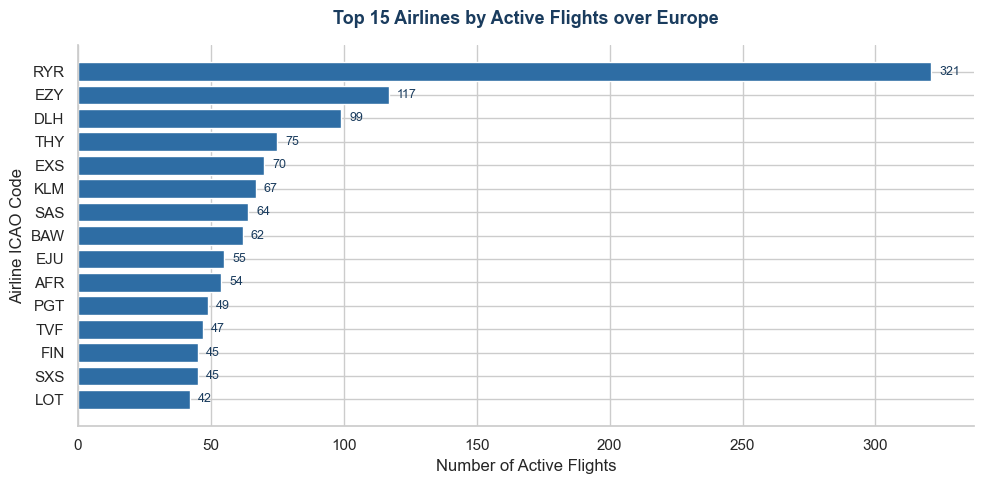

✅ Chart saved as chart1_top_airlines.png


In [ ]:
# ============================================================
# CELL 7 — First visualisation: Top airlines by flight count
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
NAVY = "#1A3C5E"
BLUE = "#2E6DA4"

# --- Chart 1: Top 15 airlines by number of flights ---
top_airlines = (
    df_clean["airline_code"]
    .value_counts()
    .head(15)
    .reset_index()
)
top_airlines.columns = ["airline_code", "num_flights"]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    top_airlines["airline_code"][::-1],  # reverse so biggest is on top
    top_airlines["num_flights"][::-1],
    color=BLUE,
    edgecolor="white"
)

for bar, val in zip(bars, top_airlines["num_flights"][::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9, color=NAVY)

ax.set_title("Top 15 Airlines by Active Flights over Europe", 
             fontsize=13, fontweight="bold", color=NAVY, pad=15)
ax.set_xlabel("Number of Active Flights")
ax.set_ylabel("Airline ICAO Code")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("chart1_top_airlines.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Chart saved as chart1_top_airlines.png")

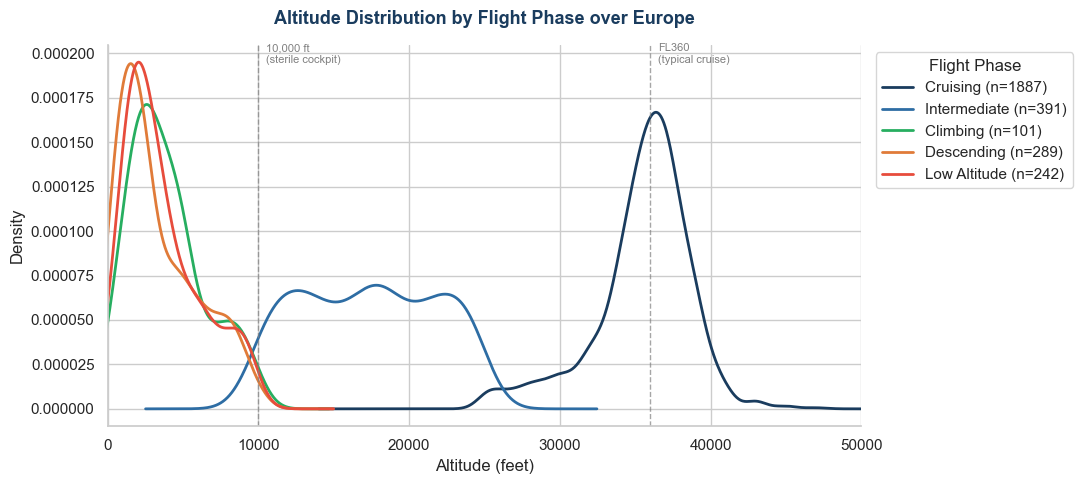

✅ Chart saved as chart2_altitude_distribution.png


In [ ]:
# ============================================================
# CELL 8 — Chart 2: Altitude distribution by flight phase
# ============================================================

phase_colors = {
    "Cruising"     : "#1A3C5E",
    "Intermediate" : "#2E6DA4",
    "Climbing"     : "#27AE60",
    "Descending"   : "#E07B39",
    "Low Altitude" : "#E74C3C"
}

fig, ax = plt.subplots(figsize=(11, 5))

# Plot one line per flight phase showing altitude distribution
for phase, color in phase_colors.items():
    subset = df_clean[df_clean["flight_phase"] == phase]["altitude_ft"]
    subset.plot.kde(ax=ax, label=f"{phase} (n={len(subset)})",
                   color=color, linewidth=2)

# Add a vertical line at 10,000 ft — significant in aviation (sterile cockpit rule)
ax.axvline(x=10000, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.text(10500, ax.get_ylim()[1] * 0.95, "10,000 ft\n(sterile cockpit)",
        fontsize=8, color="gray")

# Add a vertical line at FL360 (36,000 ft) — typical cruise level
ax.axvline(x=36000, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.text(36500, ax.get_ylim()[1] * 0.95, "FL360\n(typical cruise)",
        fontsize=8, color="gray")

ax.set_title("Altitude Distribution by Flight Phase over Europe",
             fontsize=13, fontweight="bold", color="#1A3C5E", pad=15)
ax.set_xlabel("Altitude (feet)")
ax.set_ylabel("Density")
ax.legend(title="Flight Phase", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 50000)

plt.tight_layout()
plt.savefig("chart2_altitude_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Chart saved as chart2_altitude_distribution.png")

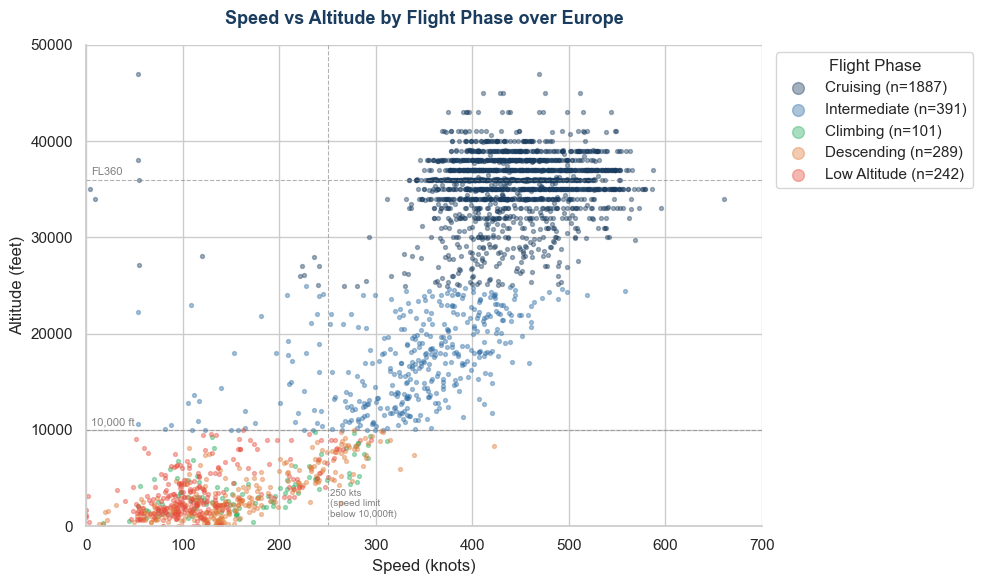

✅ Chart saved as chart3_speed_vs_altitude.png


In [ ]:
# ============================================================
# CELL 9 — Chart 3: Speed vs Altitude coloured by flight phase
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each flight phase as a separate scatter group
for phase, color in phase_colors.items():
    subset = df_clean[df_clean["flight_phase"] == phase]
    ax.scatter(
        subset["velocity_kts"],
        subset["altitude_ft"],
        c=color,
        label=f"{phase} (n={len(subset)})",
        alpha=0.4,
        s=8
    )

ax.axhline(y=10000, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(5, 10500, "10,000 ft", fontsize=8, color="gray")

ax.axhline(y=36000, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(5, 36500, "FL360", fontsize=8, color="gray")

ax.axvline(x=250, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(252, 1000, "250 kts\n(speed limit\nbelow 10,000ft)",
        fontsize=7, color="gray")

ax.set_title("Speed vs Altitude by Flight Phase over Europe",
             fontsize=13, fontweight="bold", color="#1A3C5E", pad=15)
ax.set_xlabel("Speed (knots)")
ax.set_ylabel("Altitude (feet)")
ax.legend(title="Flight Phase", bbox_to_anchor=(1.01, 1), loc="upper left",
          markerscale=3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 700)
ax.set_ylim(0, 50000)

plt.tight_layout()
plt.savefig("chart3_speed_vs_altitude.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Chart saved as chart3_speed_vs_altitude.png")

In [11]:
# ============================================================
# CELL 10 — Summary statistics for the README
# ============================================================

print("=== PROJECT SUMMARY STATS ===")
print(f"Total aircraft analysed  : {len(df_clean):,}")
print(f"Countries represented    : {df_clean['origin_country'].nunique()}")
print(f"Unique airlines          : {df_clean['airline_code'].nunique()}")
print(f"Avg cruise altitude      : {cruising['altitude_ft'].mean():,.0f} ft")
print(f"Avg cruise speed         : {cruising['velocity_kts'].mean():,.0f} kts")
print(f"Highest cruising aircraft: {cruising['altitude_ft'].max():,.0f} ft")
print(f"Top airline              : RYR (Ryanair) with "
      f"{df_clean[df_clean['airline_code']=='RYR'].shape[0]} flights")
print()
print("=== FLIGHT PHASE BREAKDOWN ===")
phase_pct = df_clean["flight_phase"].value_counts(normalize=True) * 100
for phase, pct in phase_pct.items():
    print(f"  {phase:<15}: {pct:.1f}%")

=== PROJECT SUMMARY STATS ===
Total aircraft analysed  : 2,910
Countries represented    : 76
Unique airlines          : 513
Avg cruise altitude      : 35,507 ft
Avg cruise speed         : 443 kts
Highest cruising aircraft: 47,000 ft
Top airline              : RYR (Ryanair) with 321 flights

=== FLIGHT PHASE BREAKDOWN ===
  Cruising       : 64.8%
  Intermediate   : 13.4%
  Descending     : 9.9%
  Low Altitude   : 8.3%
  Climbing       : 3.5%
